In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

In [17]:
def f(x, mu, w=0.1):
    y = np.zeros_like(x)
    y[np.abs(x-mu)<(w+1e-6)] = 1
    return y

def f1(x, mu, w=0.1):
    # make f HWS
    return f(x-1, mu, w)+f(x, mu, w)+f(x+1, mu, w)


def f3(x, mu, w=0.1, s=0.15):
    # gaussian smoothing
    y = f1(x, mu, w)
    dx = x[1]-x[0]  # 1/m
    y2 = gaussian_filter1d(y, sigma=s/dx, mode="wrap")
    return y2

In [18]:
def get_trig_basis(x, M):
    n = 2*M-1
    U = np.empty((len(x), n))
    U[:, 0] = 1 / len(x)**.5
    for m in range(1, M):
        U[:, 2*m-1] = 2**.5 * np.sin(2*np.pi*m*x) / len(x)**.5
        U[:, 2*m] = 2**.5 * np.cos(2*np.pi*m*x) / len(x)**.5
    return U

In [19]:
m = n = 1000
dx = 1/m
x = np.linspace(0, 1, m, endpoint=False)+dx/2
mus = x.copy()

# equ. 2

In [20]:
u = f1(x, 0.5)
sgms = np.linspace(0, .1, 500)[1:]
e_L2 = np.empty_like(sgms)
for i, sig in enumerate(sgms):
    u_sig = f3(x, 0.5, s=sig)
    e_L2[i] = np.linalg.norm(u-u_sig) / m**.5

(0.0, 0.5)

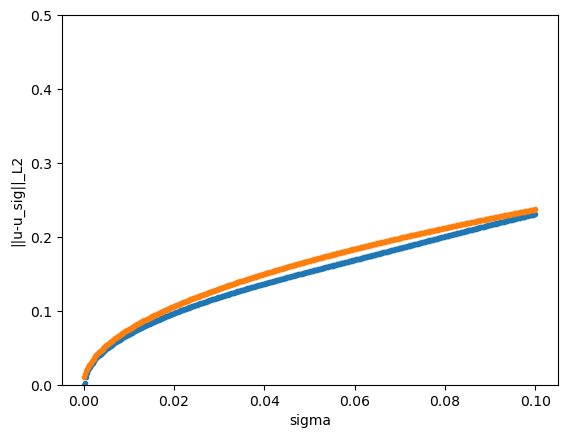

In [30]:
plt.plot(sgms, e_L2, "C0.")
#plt.plot(sgms, 20*sgms, "C1.")
plt.plot(sgms, .75*sgms**.5, "C1.")
plt.xlabel("sigma")
plt.ylabel("||u-u_sig||_L2")
plt.ylim(0, 0.5)

Text(0, 0.5, 'C')

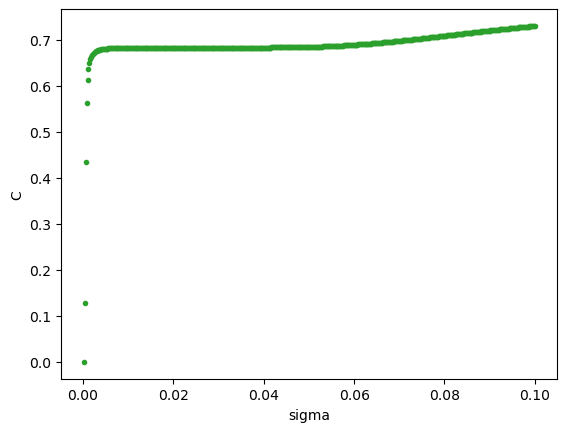

In [28]:
#plt.plot(sgms, e_L2/sgms, "C2.")
plt.plot(sgms, e_L2/sgms**.5, "C2.")
plt.xlabel("sigma")
plt.ylabel("C")

# equ. 3


In [8]:
X = np.empty((m, n))
Xs = np.empty((m, n))
for j in range(n):
    mu = mus[j]
    X[:, j] = f1(x, mu)
    Xs[:, j] = f3(x, mu, s=0.005)

In [9]:
#X = Xs  # m, n
U = get_trig_basis(x, M=m//2)  # m, r
SVT = U.T@Xs  # r, n
S = np.sum(SVT**2, axis=1)
delta_n = (np.cumsum(S[::-1]**2)[::-1]/m/n)**.5


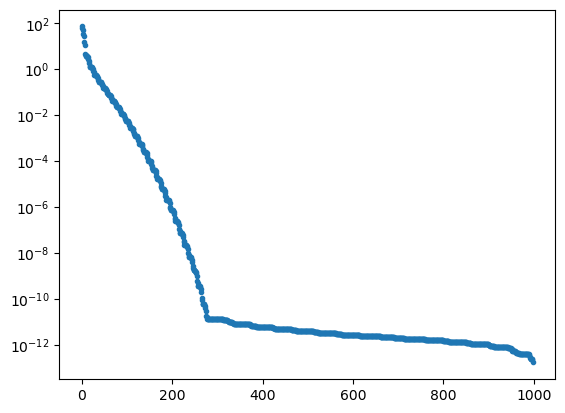

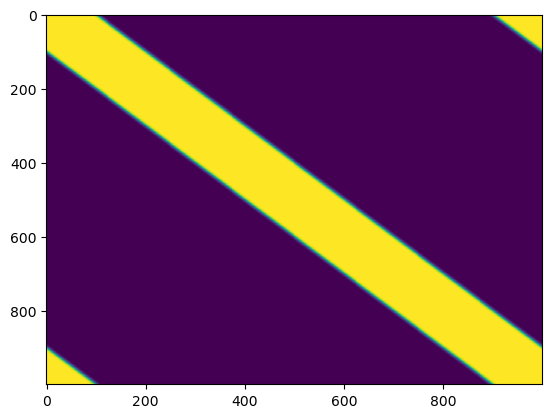

In [10]:
plt.plot(delta_n, "C0.")
#plt.plot(1000/np.arange(len(S)), "C1.")
plt.gca().set_yscale("log")
plt.show()
plt.imshow(Xs, interpolation="nearest")
plt.gca().set_aspect("auto")
plt.show()


## equ 8

0.02
0.01
0.005
0.002
0.001


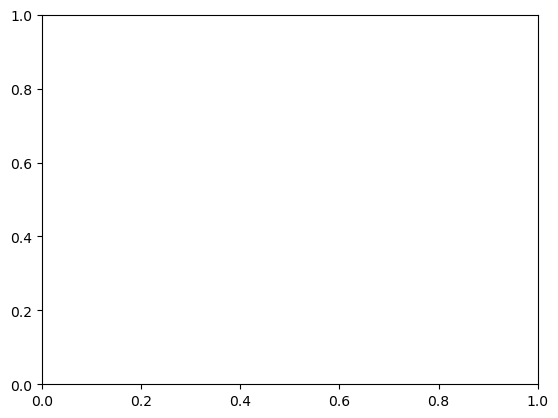

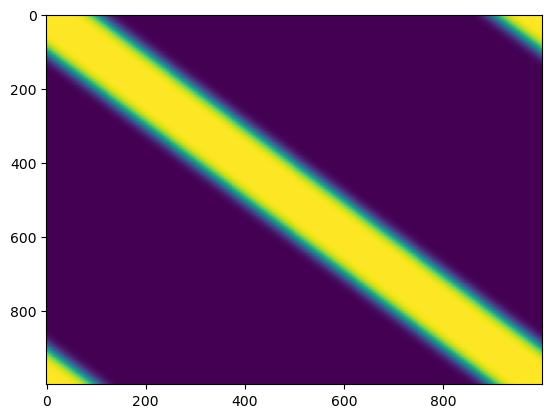

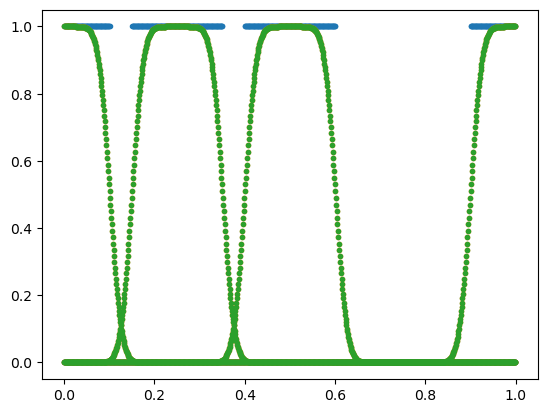

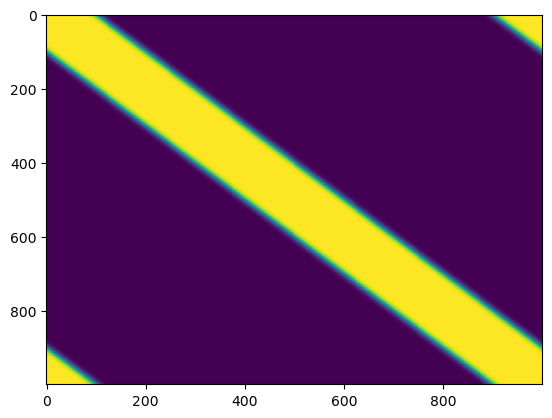

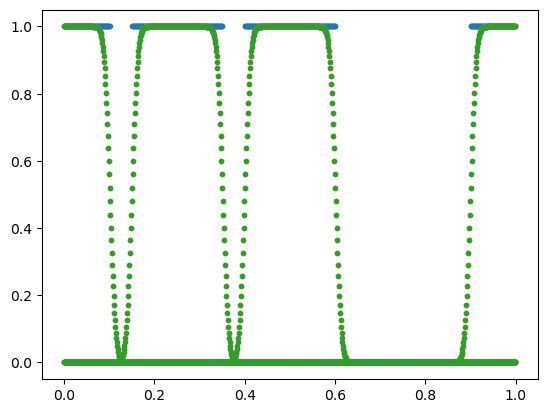

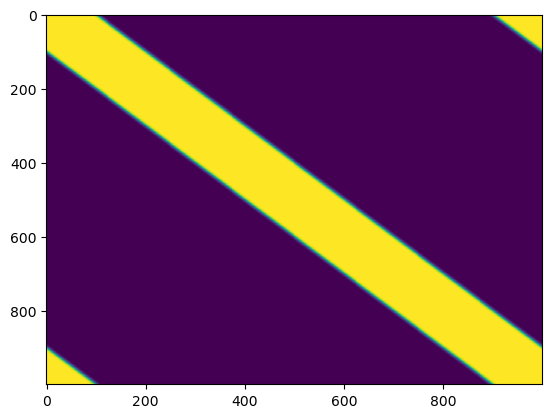

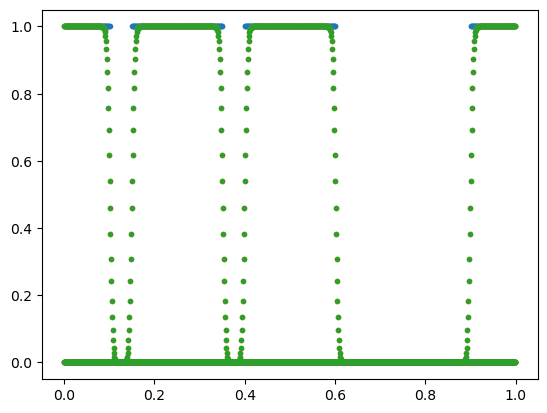

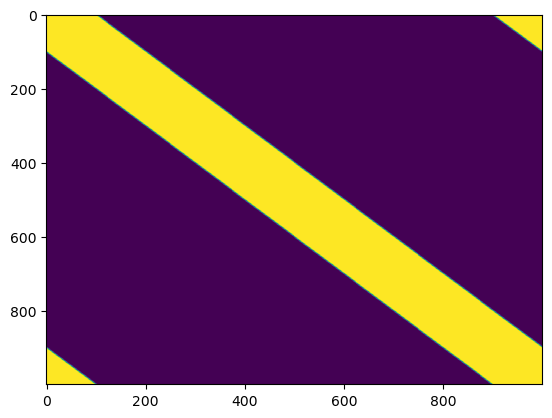

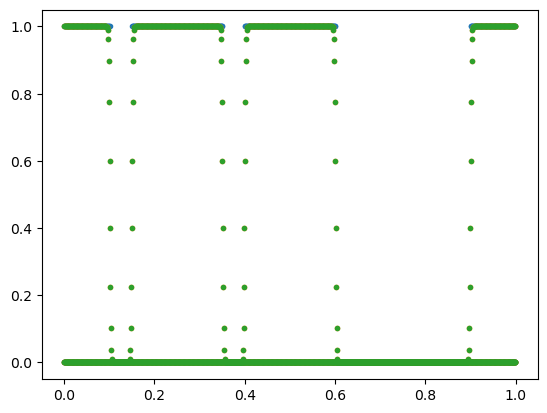

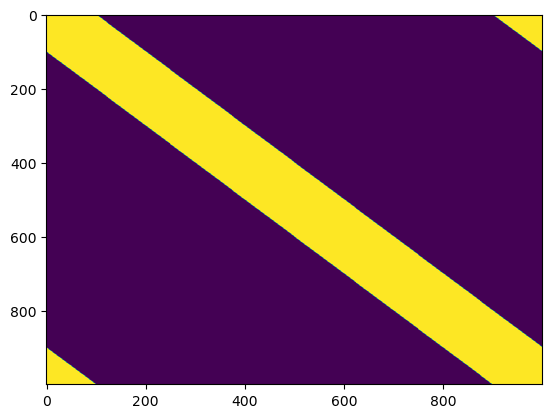

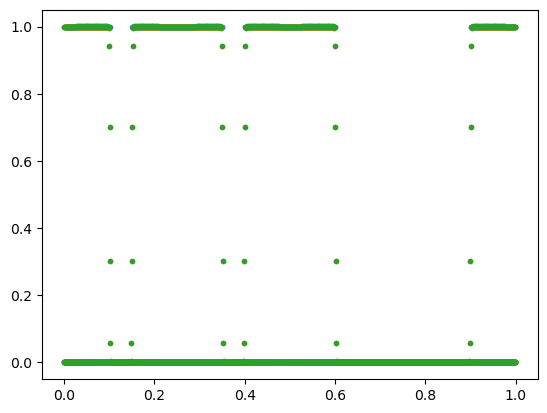

In [11]:
N = np.r_[np.arange(2, 100, 2), np.arange(100, m, 10)]
e = np.empty((5, len(N)), dtype=np.float64)

sgms = 1/np.array([50, 100, 200, 500, 1000])

for i, sig in enumerate(sgms):
    print(sig)
    for j in range(n):
        mu = mus[j]
        X[:, j] = f1(x, mu)
        Xs[:, j] = f3(x, mu, s=sig)

    for k, rank in enumerate(N):
        U_r = U[:, :rank]
        X_approx = U_r @ (U_r.T@Xs)
        e[i, k] = np.linalg.norm(X-X_approx) / m**.5
    plt.figure()
    plt.imshow(X_approx, interpolation="nearest")
    plt.gca().set_aspect("auto")
    #plt.show()
    
    plt.figure()
    plt.plot(x, X[:, 0], "C0.")
    plt.plot(x, X[:, 250], "C0.")
    plt.plot(x, X[:, 500], "C0.")
    plt.plot(x, Xs[:, 0], "C1.")
    plt.plot(x, Xs[:, 250], "C1.")
    plt.plot(x, Xs[:, 500], "C1.")
    plt.plot(x, X_approx[:, 0], "C2.")
    plt.plot(x, X_approx[:, 250], "C2.")
    plt.plot(x, X_approx[:, 500], "C2.")
    plt.show()

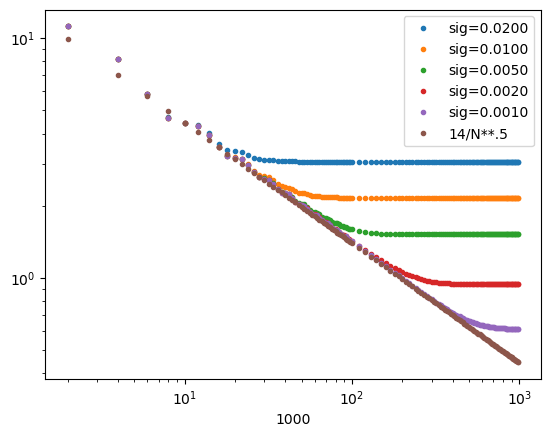

In [14]:
fig, ax = plt.subplots()
for i, sig in enumerate(sgms):    
    ax.plot(N, e[i], ".", label="sig={:.4f}".format(sig))
ax.set_yscale("log")
ax.set_xscale("log")
ax.plot(N, 14/N**.5, ".", label="14/N**.5")
#plt.title("sig={:.4f}".format(sig))
ax.legend()
plt.xlabel(n)
plt.show()